In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


In [13]:
data = pd.read_csv("E:\ANN_projects\crop_recommendation_dataset.csv")
data.head()

,Nitrogen,Phosphorous,Potassium,Temperature,Humidity,PH_Value,Rainfall,Crop
0,77,60,52,34.27,82.34,6.14,279.09,rice
1,71,39,45,26.31,74.21,5.07,232.50,rice
2,70,42,49,23.01,71.34,5.05,166.66,rice
3,65,51,43,28.93,85.06,5.93,206.22,rice
4,65,38,56,30.51,82.86,6.32,293.03,rice


In [14]:
pd.unique(data['Crop'])

array(['rice', 'wheat', 'maize', 'cotton', 'sugarcane', 'banana'],
      dtype=object)

In [15]:
pd.value_counts(data["Crop"])

E:\pip-temp\ipykernel_17016\3513370621.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(data["Crop"])


Crop
rice         50
wheat        50
maize        50
cotton       50
sugarcane    50
banana       50
Name: count, dtype: int64

In [16]:
X,Y = data.iloc[:,:-1] , data['Crop']
X.head()


,Nitrogen,Phosphorous,Potassium,Temperature,Humidity,PH_Value,Rainfall
0,77,60,52,34.27,82.34,6.14,279.09
1,71,39,45,26.31,74.21,5.07,232.50
2,70,42,49,23.01,71.34,5.05,166.66
3,65,51,43,28.93,85.06,5.93,206.22
4,65,38,56,30.51,82.86,6.32,293.03


In [17]:
X = X.reset_index(drop=True)
X

,Nitrogen,Phosphorous,Potassium,Temperature,Humidity,PH_Value,Rainfall
0,77,60,52,34.27,82.34,6.14,279.09
1,71,39,45,26.31,74.21,5.07,232.50
2,70,42,49,23.01,71.34,5.05,166.66
3,65,51,43,28.93,85.06,5.93,206.22
4,65,38,56,30.51,82.86,6.32,293.03
...,...,...,...,...,...,...,...
295,89,58,87,26.53,65.22,6.15,151.94
296,92,58,81,27.89,75.10,7.18,145.33
297,92,70,54,34.45,87.64,6.05,204.06
298,98,63,77,24.50,85.49,5.77,132.64


<Axes: >

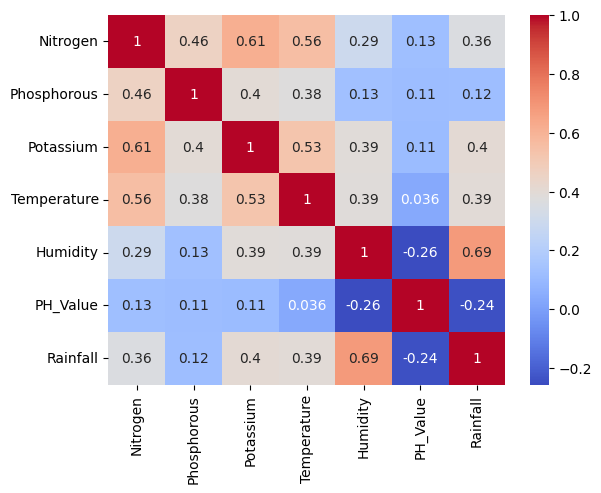

In [18]:
X_corr = X.corr()
sns.heatmap(X_corr , annot=True , cmap='coolwarm')

In [19]:
X= X.drop(columns=["Phosphorous"])
X

,Nitrogen,Potassium,Temperature,Humidity,PH_Value,Rainfall
0,77,52,34.27,82.34,6.14,279.09
1,71,45,26.31,74.21,5.07,232.50
2,70,49,23.01,71.34,5.05,166.66
3,65,43,28.93,85.06,5.93,206.22
4,65,56,30.51,82.86,6.32,293.03
...,...,...,...,...,...,...
295,89,87,26.53,65.22,6.15,151.94
296,92,81,27.89,75.10,7.18,145.33
297,92,54,34.45,87.64,6.05,204.06
298,98,77,24.50,85.49,5.77,132.64


In [20]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X.values)
X_scaled = pd.DataFrame(scaled_data , columns=X.columns)
X_scaled.head()

,Nitrogen,Potassium,Temperature,Humidity,PH_Value,Rainfall
0,-0.394452,0.033705,1.205046,1.150858,-0.646317,1.961300
1,-0.643231,-0.392680,-0.054992,0.499126,-2.228471,1.246426
2,-0.684694,-0.149032,-0.577370,0.269056,-2.258044,0.236182
3,-0.892009,-0.514505,0.359744,1.368904,-0.956833,0.843188
4,-0.892009,0.277353,0.609852,1.192543,-0.380161,2.175195


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score , f1_score
from sklearn.model_selection import GridSearchCV

X_train , X_test , y_train , y_test = train_test_split(X_scaled,Y , test_size=0.2 , random_state=42)


param_grid = {
    'criterion':['gini','entropy'] , 
    'max_depth':[None , 5 ,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

clf = DecisionTreeClassifier()
grid_search = GridSearchCV(estimator=clf , param_grid=param_grid , cv=5 , scoring='accuracy')
grid_search.fit(X_train , y_train)







,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [22]:
reasults = pd.DataFrame(grid_search.cv_results_)
reasults.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.023875,0.025767,0.008825,0.006138,gini,None,1,2,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.604167,0.625000,0.687500,0.770833,0.625000,0.662500,0.060953,37
1,0.015554,0.011727,0.004373,0.000669,gini,None,1,5,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.645833,0.625000,0.729167,0.666667,0.708333,0.675000,0.038640,20
2,0.017566,0.019767,0.008147,0.004408,gini,None,1,10,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.645833,0.604167,0.708333,0.708333,0.729167,0.679167,0.046771,17
3,0.004343,0.001936,0.002665,0.001574,gini,None,2,2,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.666667,0.604167,0.666667,0.708333,0.708333,0.670833,0.038188,29
4,0.007413,0.003437,0.004478,0.004943,gini,None,2,5,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.645833,0.583333,0.645833,0.687500,0.708333,0.654167,0.042898,40


In [23]:
best_params = grid_search.best_params_
print("Best Hyperparameters: " , best_params)
best_clf = DecisionTreeClassifier(**best_params)
best_clf.fit(X_train , y_train)
y_pred = best_clf.predict(X_test)
accuracy = accuracy_score(y_test ,y_pred)
print("Accuracy:" , accuracy)

Best Hyperparameters:  {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
Accuracy: 0.7


In [24]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
xgb_clf = XGBClassifier()
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(Y)
X_train , X_test , Y_trainXG , y_tesrXG = train_test_split(X_scaled , y_encoded , test_size=0.2 , random_state=42)

param_gridX={
    'max_depth':[3,5,7],
    'learning_rate':[0.1,0.01,0.001],
    'n_estimators':[100,200,300]
}
grid_serachXG = GridSearchCV(estimator=xgb_clf , param_grid=param_gridX , cv=5 , scoring='accuracy')
grid_serachXG.fit(X_train , Y_trainXG)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.1, 0.01, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [25]:
reasultsXG = pd.DataFrame(grid_serachXG.cv_results_)
reasults.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.023875,0.025767,0.008825,0.006138,gini,None,1,2,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.604167,0.625000,0.687500,0.770833,0.625000,0.662500,0.060953,37
1,0.015554,0.011727,0.004373,0.000669,gini,None,1,5,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.645833,0.625000,0.729167,0.666667,0.708333,0.675000,0.038640,20
2,0.017566,0.019767,0.008147,0.004408,gini,None,1,10,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.645833,0.604167,0.708333,0.708333,0.729167,0.679167,0.046771,17
3,0.004343,0.001936,0.002665,0.001574,gini,None,2,2,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.666667,0.604167,0.666667,0.708333,0.708333,0.670833,0.038188,29
4,0.007413,0.003437,0.004478,0.004943,gini,None,2,5,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.645833,0.583333,0.645833,0.687500,0.708333,0.654167,0.042898,40


In [27]:
best_paramsXG = grid_serachXG.best_params_
print("Best Hypeparameters :" , best_params)

best_xgb_clf = XGBClassifier(**best_paramsXG)
best_xgb_clf.fit(X_train , Y_trainXG)

y_predXG = best_xgb_clf.predict(X_test)

accuracy = accuracy_score(y_tesrXG ,y_predXG)
print("accuracy : " , accuracy)

Best Hypeparameters : {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
accuracy :  0.8333333333333334
